# Mini Project: Data Visualization with Pandas, Seaborn, and Matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset — 'NA' strings must be treated as NaN
df = pd.read_csv('Palmer_Penguins_Dataset.csv', na_values='NA')

print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())

# Drop rows where all key measurements are missing
df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])

# Standardise 'sex' column (strip spaces, lowercase)
df['sex'] = df['sex'].str.strip().str.lower()

# Keep only valid sex values
df = df[df['sex'].isin(['male', 'female'])]

print('\nCleaned shape:', df.shape)
df.head()

Shape: (344, 8)

Column types:
 species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

Missing values:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Cleaned shape: (333, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [3]:
# Key statistics
print('=== Summary Statistics ===')
print(df.describe())

print('\n=== Unique Species ===')
print(df['species'].unique())

print('\n=== Unique Islands ===')
print(df['island'].unique())

print('\n=== Species Counts ===')
print(df['species'].value_counts())

print('\n=== Island Counts ===')
print(df['island'].value_counts())

print('\n=== Flipper Length Range ===')
print(f"Min: {df['flipper_length_mm'].min()} mm  |  Max: {df['flipper_length_mm'].max()} mm")

=== Summary Statistics ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      333.000000     333.000000         333.000000   333.000000   
mean        43.992793      17.164865         200.966967  4207.057057   
std          5.468668       1.969235          14.015765   805.215802   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.500000      15.600000         190.000000  3550.000000   
50%         44.500000      17.300000         197.000000  4050.000000   
75%         48.600000      18.700000         213.000000  4775.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   333.000000  
mean   2008.042042  
std       0.812944  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  

=== Unique Species ===
['Adelie' 'Gentoo' 'Chinstrap']

=== Unique Islands ===
['Torgersen' 'Biscoe' 'Dream']

=== Species Counts ===


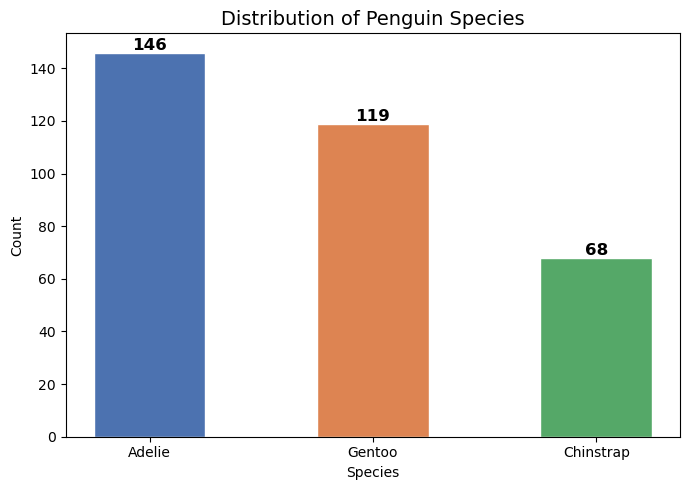

Insight: Adelie is the most common species, followed by Gentoo and Chinstrap.


In [4]:
species_counts = df['species'].value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(species_counts.index, species_counts.values,
               color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', width=0.5)

# Add count labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')

plt.title('Distribution of Penguin Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Interpretation
print('Insight: Adelie is the most common species, followed by Gentoo and Chinstrap.')

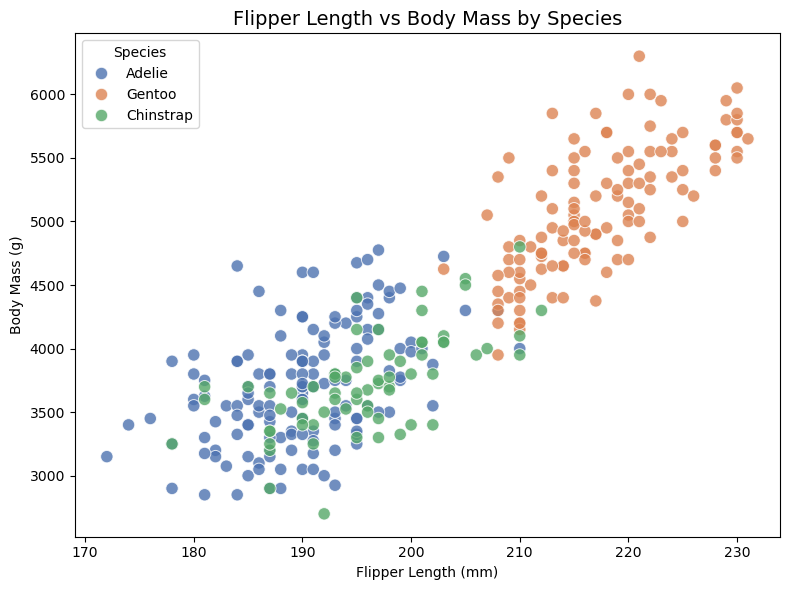

Insight: Gentoo penguins have both the longest flippers and the highest body mass.


In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g',
                hue='species', palette='deep', s=80, alpha=0.8)

plt.title('Flipper Length vs Body Mass by Species', fontsize=14)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

print('Insight: Gentoo penguins have both the longest flippers and the highest body mass.')

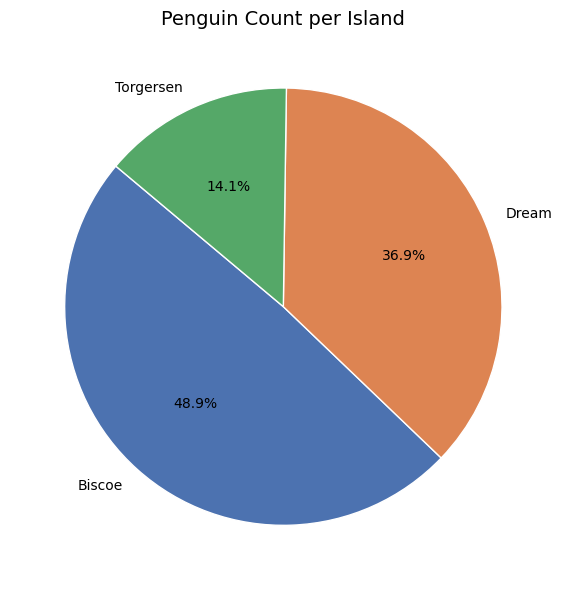

Insight: Biscoe island hosts the most penguins, largely due to the Gentoo population.


In [6]:
island_counts = df['island'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(island_counts.values, labels=island_counts.index,
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452', '#55A868'],
        startangle=140, wedgeprops={'edgecolor': 'white'})

plt.title('Penguin Count per Island', fontsize=14)
plt.tight_layout()
plt.show()

print('Insight: Biscoe island hosts the most penguins, largely due to the Gentoo population.')

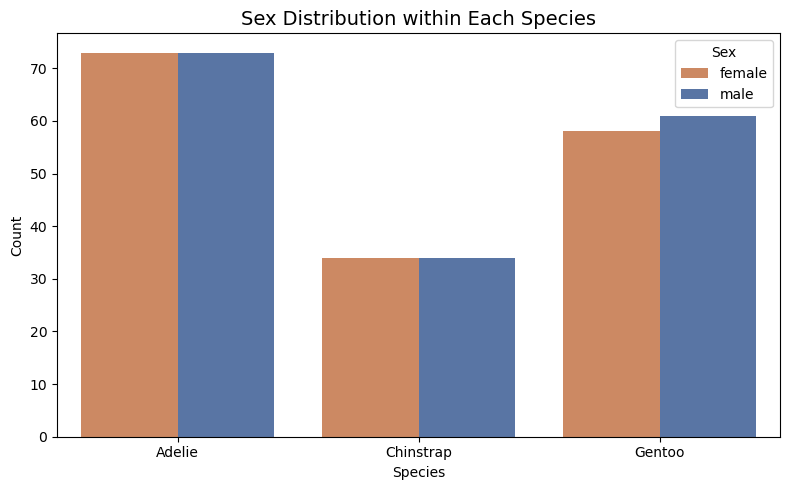

Insight: Sex is roughly balanced within each species.


In [7]:
sex_species = df.groupby(['species', 'sex']).size().reset_index(name='count')

plt.figure(figsize=(8, 5))
sns.barplot(data=sex_species, x='species', y='count', hue='sex',
            palette={'male': '#4C72B0', 'female': '#DD8452'})

plt.title('Sex Distribution within Each Species', fontsize=14)
plt.xlabel('Species')
plt.ylabel('Count')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

print('Insight: Sex is roughly balanced within each species.')

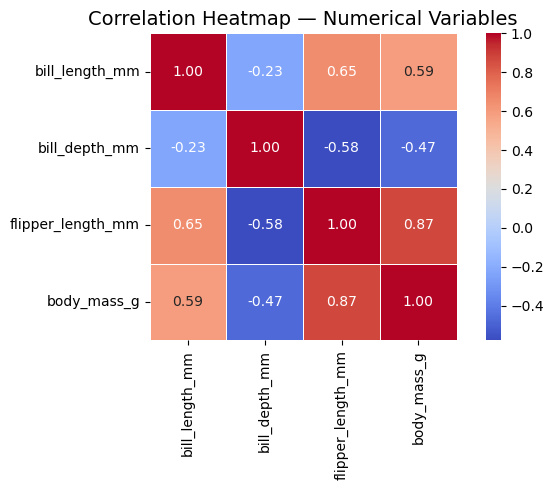

Insight: Flipper length and body mass are strongly positively correlated (≈0.87).


In [8]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)

plt.title('Correlation Heatmap — Numerical Variables', fontsize=14)
plt.tight_layout()
plt.show()

print('Insight: Flipper length and body mass are strongly positively correlated (≈0.87).')

C:\Users\hp\AppData\Local\Temp\ipykernel_5688\2335004828.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='deep', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_5688\2335004828.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='deep', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_5688\2335004828.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='deep', ax=ax)
C:\Users\hp\AppData\Local\Temp\ipykernel_5688\2335004828.py:1

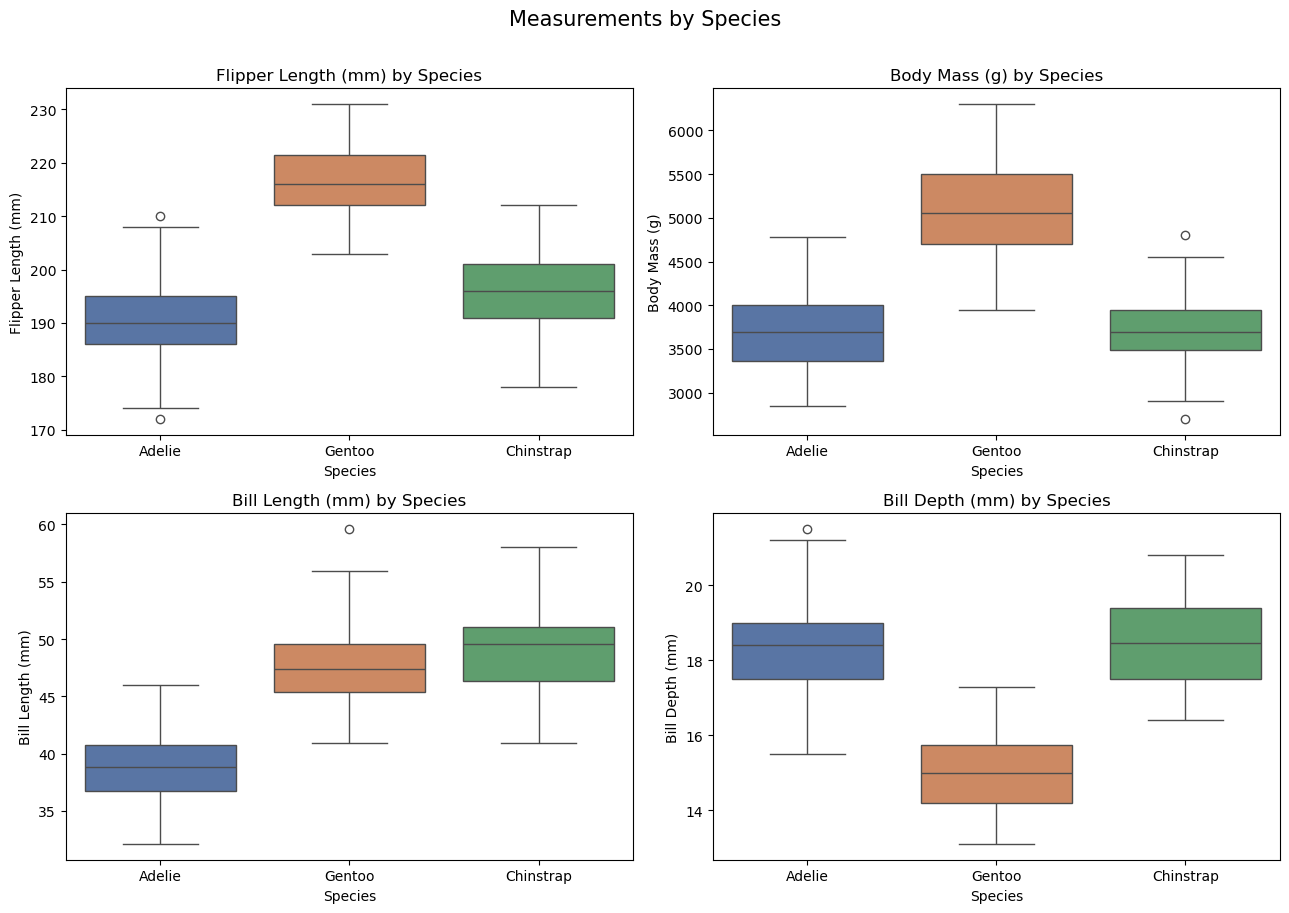

Insight: Gentoo has the largest body mass and flipper length; Chinstrap has the longest bill.


In [9]:
measurements = {
    'flipper_length_mm': 'Flipper Length (mm)',
    'body_mass_g':       'Body Mass (g)',
    'bill_length_mm':    'Bill Length (mm)',
    'bill_depth_mm':     'Bill Depth (mm)'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (col, label) in zip(axes.flat, measurements.items()):
    sns.boxplot(data=df, x='species', y=col, palette='deep', ax=ax)
    ax.set_title(f'{label} by Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(label)

plt.suptitle('Measurements by Species', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print('Insight: Gentoo has the largest body mass and flipper length; Chinstrap has the longest bill.')

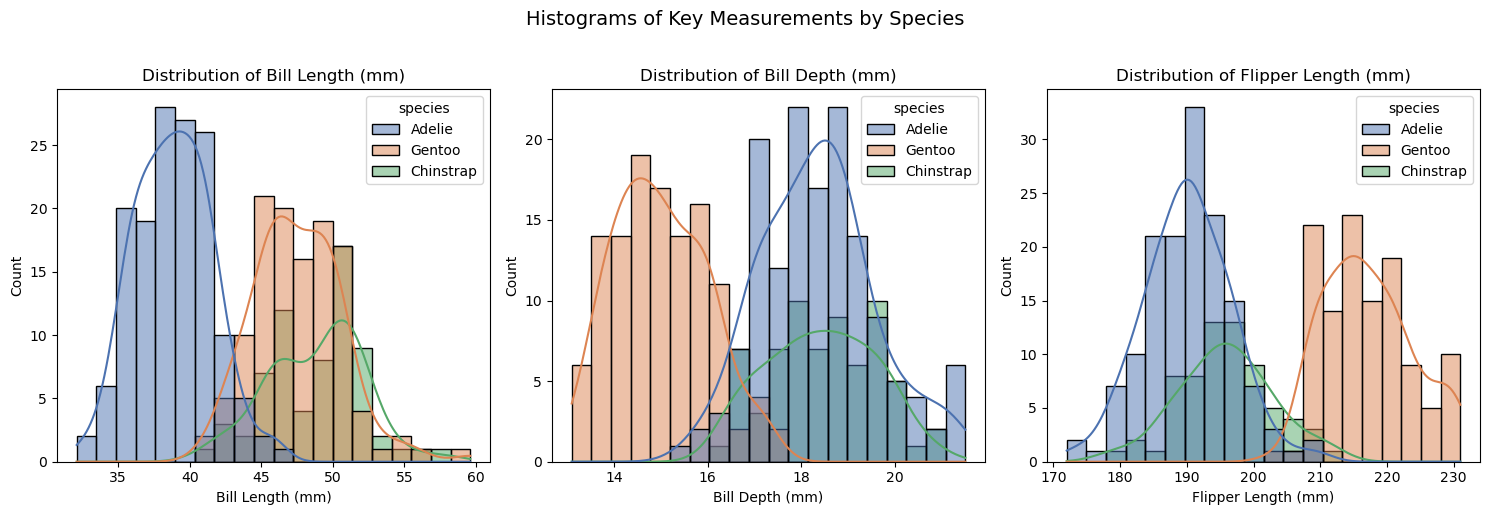

Insight: Gentoo shows a clearly separate distribution for both flipper length and bill depth.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

hist_cols = [
    ('bill_length_mm',    'Bill Length (mm)'),
    ('bill_depth_mm',     'Bill Depth (mm)'),
    ('flipper_length_mm', 'Flipper Length (mm)'),
]

for ax, (col, label) in zip(axes, hist_cols):
    sns.histplot(data=df, x=col, hue='species', kde=True, palette='deep', ax=ax, bins=20)
    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')

plt.suptitle('Histograms of Key Measurements by Species', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Insight: Gentoo shows a clearly separate distribution for both flipper length and bill depth.')

C:\Users\hp\AppData\Local\Temp\ipykernel_5688\3053783374.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='flipper_length_mm', palette='deep', ax=ax4)


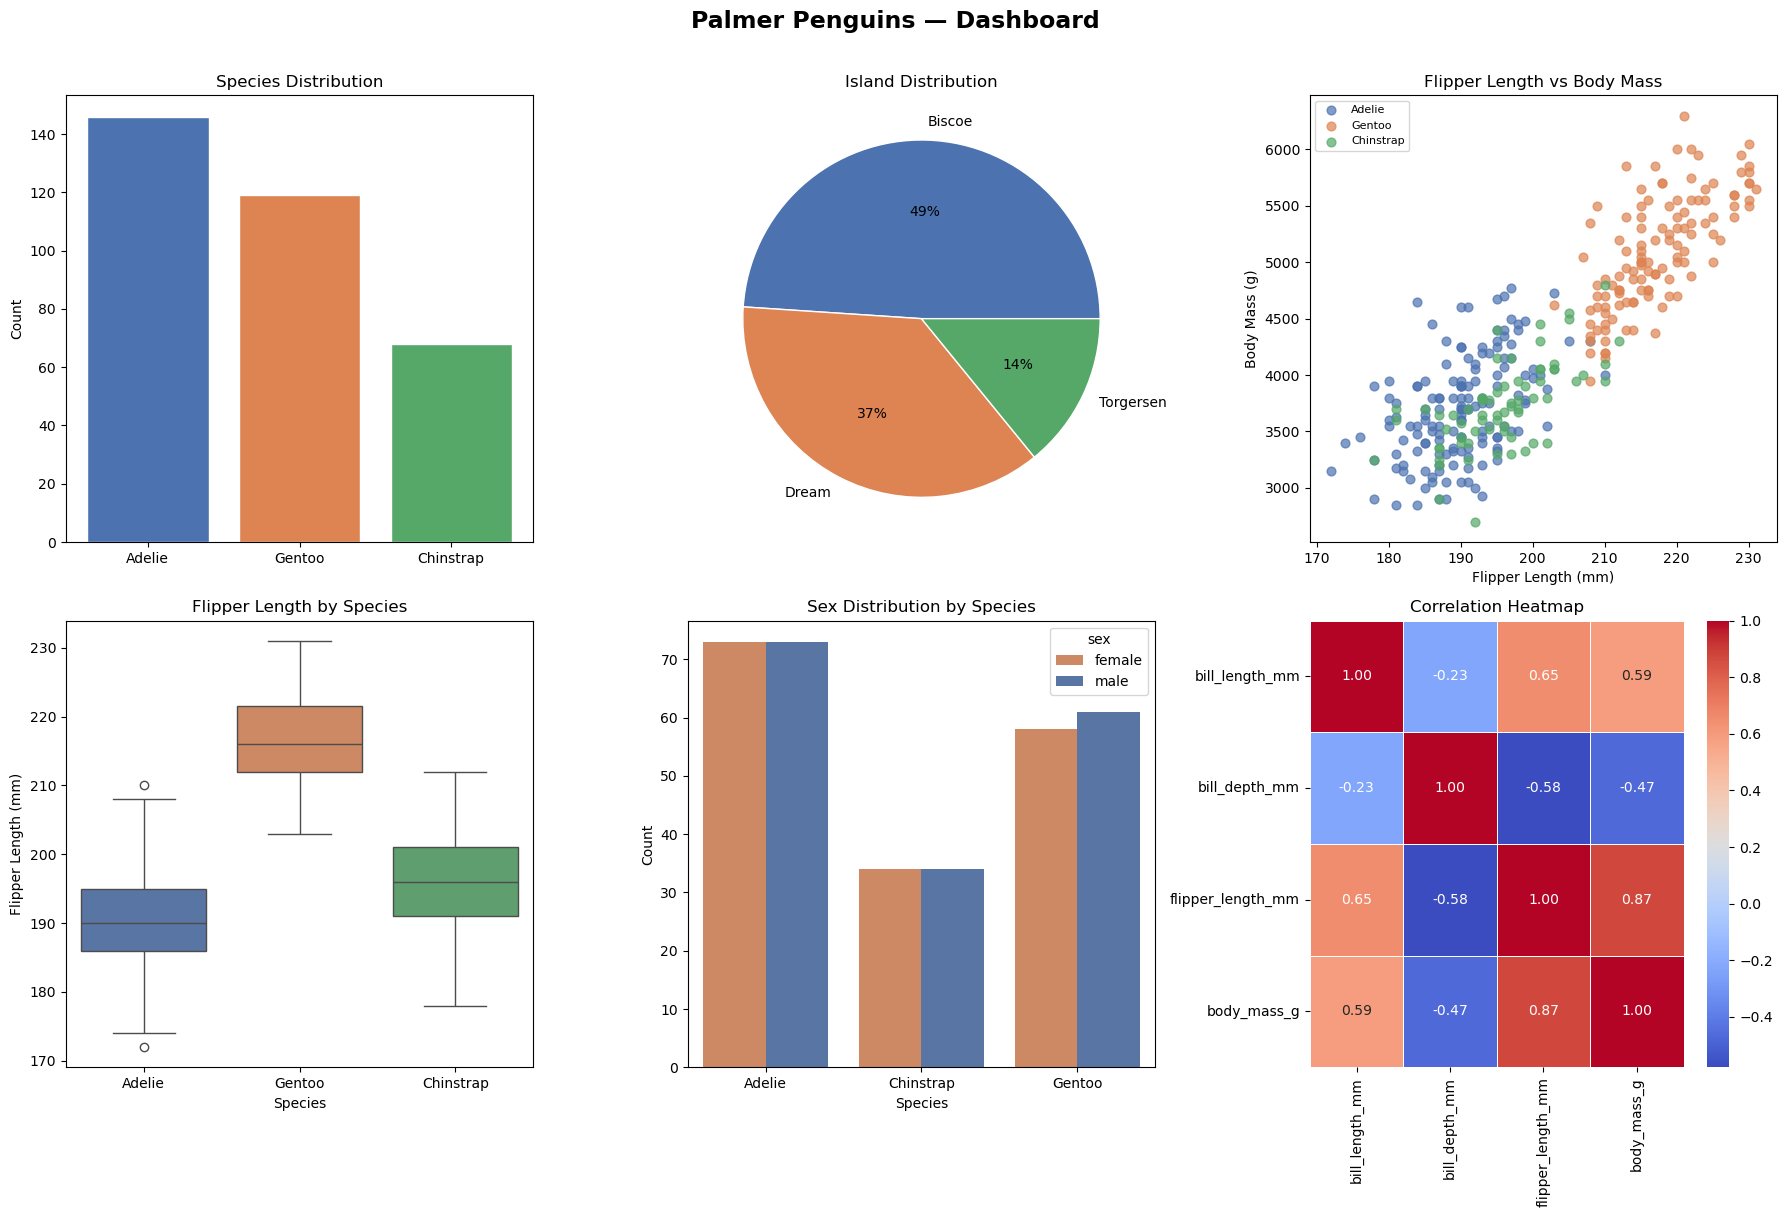

In [11]:
fig = plt.figure(figsize=(18, 12))

# --- Top left: Species bar chart ---
ax1 = fig.add_subplot(2, 3, 1)
species_counts = df['species'].value_counts()
ax1.bar(species_counts.index, species_counts.values,
        color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white')
ax1.set_title('Species Distribution')
ax1.set_ylabel('Count')

# --- Top center: Island pie chart ---
ax2 = fig.add_subplot(2, 3, 2)
island_counts = df['island'].value_counts()
ax2.pie(island_counts.values, labels=island_counts.index,
        autopct='%1.0f%%', colors=['#4C72B0', '#DD8452', '#55A868'],
        wedgeprops={'edgecolor': 'white'})
ax2.set_title('Island Distribution')

# --- Top right: Scatter flipper vs mass ---
ax3 = fig.add_subplot(2, 3, 3)
for sp, color in zip(df['species'].unique(), ['#4C72B0', '#DD8452', '#55A868']):
    sub = df[df['species'] == sp]
    ax3.scatter(sub['flipper_length_mm'], sub['body_mass_g'],
                label=sp, alpha=0.7, color=color, s=40)
ax3.set_title('Flipper Length vs Body Mass')
ax3.set_xlabel('Flipper Length (mm)')
ax3.set_ylabel('Body Mass (g)')
ax3.legend(fontsize=8)

# --- Bottom left: Boxplot flipper length ---
ax4 = fig.add_subplot(2, 3, 4)
sns.boxplot(data=df, x='species', y='flipper_length_mm', palette='deep', ax=ax4)
ax4.set_title('Flipper Length by Species')
ax4.set_xlabel('Species')
ax4.set_ylabel('Flipper Length (mm)')

# --- Bottom center: Grouped bar sex ---
ax5 = fig.add_subplot(2, 3, 5)
sex_species = df.groupby(['species', 'sex']).size().reset_index(name='count')
sns.barplot(data=sex_species, x='species', y='count', hue='sex',
            palette={'male': '#4C72B0', 'female': '#DD8452'}, ax=ax5)
ax5.set_title('Sex Distribution by Species')
ax5.set_xlabel('Species')
ax5.set_ylabel('Count')

# --- Bottom right: Heatmap ---
ax6 = fig.add_subplot(2, 3, 6)
corr = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax6, linewidths=0.5)
ax6.set_title('Correlation Heatmap')

plt.suptitle('Palmer Penguins — Dashboard', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Kernel 11 — Pairplot

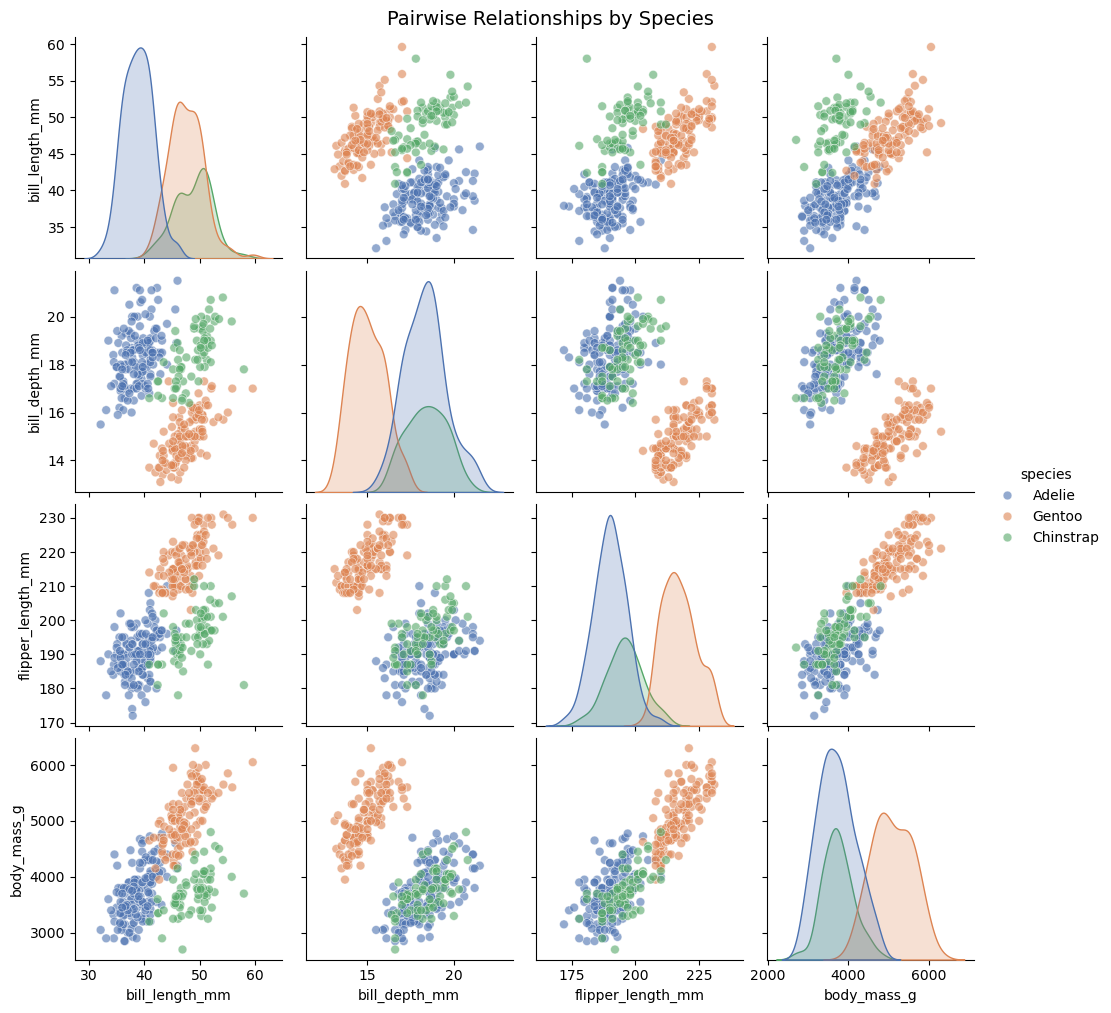

Insight: Gentoo clusters are clearly separated; Adelie and Chinstrap overlap more.


In [12]:
pair_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']

sns.pairplot(df[pair_cols], hue='species', palette='deep',
             plot_kws={'alpha': 0.6, 's': 40}, diag_kind='kde')

plt.suptitle('Pairwise Relationships by Species', fontsize=14, y=1.01)
plt.show()

print('Insight: Gentoo clusters are clearly separated; Adelie and Chinstrap overlap more.')

## Conclusion

Key insights from the Palmer Penguins dataset:

- **Species**: Adelie is the most numerous species; Chinstrap the least.
- **Islands**: Biscoe hosts the most penguins (dominated by Gentoo); Chinstrap lives exclusively on Dream Island.
- **Size**: Gentoo penguins are the largest (highest body mass and longest flippers), while Chinstrap have the longest bills.
- **Correlations**: Flipper length and body mass are strongly correlated (≈0.87), making flipper length a good predictor of size.
- **Sex**: The male/female split is roughly balanced across all three species.
- **Separability**: Gentoo is visually the most distinct species across all measurements; this dataset is well-suited for classification tasks.